In [7]:
#Inicio importando las librerias que necesito
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt 
from pathlib import Path  
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

print(f"Librerias importadas OK")

ModuleNotFoundError: No module named 'pandas'

In [ ]:

#Carga del dataset de Sabadell en Python, se agrego la libreria
##from pathlib import Path para que suba sin necesidad de colocar el directorio
# en el df_datasabadell se demora uno aproximadamente 4 seg porque es de 10000 registros la BD
input_dir = Path.cwd() / "input"
xlsx_files = []
if input_dir.exists():
    xlsx_files = sorted(input_dir.glob("*.xlsx"))
else:
    xlsx_files = sorted(Path.cwd().glob("*.xlsx"))

if not xlsx_files:
    raise FileNotFoundError(
        f"No se encontró ningún archivo .xlsx en {input_dir} ni en el directorio actual."
    )

excel_path = xlsx_files[0]
df_datasabadell = pd.read_excel(excel_path, engine="openpyxl")
print(f"Listo! Excel cargado desde: {excel_path}")
print(f"output_dir será: {Path.cwd() / 'output'}")


NameError: name 'Path' is not defined

In [ ]:
# Estadística descriptiva de las variables clave de perfil / consumo
vars_clave = ['antig','edad','totalpasta','renta_final','gastos_tot','nivren',
              'margecomercialut','credit','revolving','tothipo','nominaimp','rdom','tpv']
df_datasabadell[vars_clave].describe().T

,count,mean,std,min,25%,50%,75%,max
antig,10000.0,218.333500,795.911927,1.00,47.000000,121.000,233.000000,9999.00
edad,10000.0,49.354400,20.248531,0.00,36.000000,49.000,64.000000,116.00
totalpasta,10000.0,23847.890669,86505.052000,0.00,287.467500,2123.225,17078.425000,4798534.49
renta_final,7239.0,25369.533403,81677.699690,4367.76,12310.628077,16479.540,25385.683636,4496606.59
nivren,10000.0,1.933000,0.937869,0.00,1.000000,2.000,3.000000,5.00
margecomercialut,10000.0,128.151498,462.907653,-1961.80,6.077500,36.050,138.195000,31639.73
credit,10000.0,100.536738,2457.438350,0.00,0.000000,0.000,0.000000,134200.66
revolving,10000.0,53.858220,332.113919,0.00,0.000000,0.000,0.000000,7901.99
tothipo,10000.0,13616.248837,52116.240914,0.00,0.000000,0.000,0.000000,2538920.97
nominaimp,10000.0,1141.936248,4359.877628,0.00,0.000000,0.000,0.000000,335186.92


In [ ]:
#Función para contar la cantidad total de clientes en la BD
total_clientes=df_datasabadell.id_cliente.count()
print(f"El total de clientes registrados en la BD es : {total_clientes}")


El total de clientes registrados en la BD es : 10000


In [ ]:
#Perfilados estadisticos de los diferentes campos, se muestran valores 
#minimos y maximos. 
# Análisis:
# Edad =0.000000 corresponde a padres que crean una cuenta de ahorro para sus hijos 
# totalpasta =0.000000 corresponde a los cliente que no tiene fondos.
# impoped   = 0.000000 corresponde a los clientes que no tuvieron egresos en su cuenta 
resumen = df_datasabadell.describe()
print(resumen)

        id_cliente         antig          edad    totalpasta       impoped  \
count  10000.00000  10000.000000  10000.000000  1.000000e+04  1.000000e+04   
mean    5000.50000    218.333500     49.354400  2.384789e+04  4.945997e+03   
std     2886.89568    795.911927     20.248531  8.650505e+04  2.296940e+04   
min        1.00000      1.000000      0.000000  0.000000e+00  0.000000e+00   
25%     2500.75000     47.000000     36.000000  2.874675e+02  7.624000e+01   
50%     5000.50000    121.000000     49.000000  2.123225e+03  1.690965e+03   
75%     7500.25000    233.000000     64.000000  1.707842e+04  4.574812e+03   
max    10000.00000   9999.000000    116.000000  4.798534e+06  1.055250e+06   

            impopeh  ind_cuentaexpansion  ind_cuentaexpansionnegocios  \
count  1.000000e+04         10000.000000                 10000.000000   
mean   5.433100e+03             0.347200                     0.007000   
std    2.168653e+04             0.476104                     0.083377   
min  

In [ ]:
#Analisis de los datos atipicos, conteno e identificación 
cantidad_9999 = (df_datasabadell['antig'] == 9999).sum()
print(f"Cantidad de registros con antig == '9999, posibles datos atipicos': {cantidad_9999}")



Cantidad de registros con antig == '9999, posibles datos atipicos': 64


In [ ]:
#Se tomo la decisión de eliminar los 64 registros con esos valores antig=9999, de acuerdo al analisis realizado eran clientes que no forman parte del Banco
df_delete = df_datasabadell[df_datasabadell['antig'] == 9999].copy()
print(f"CORRECCIÓN: Registros con antig == 9999 (para eliminar): {len(df_delete)}")


CORRECCIÓN: Registros con antig == 9999 (para eliminar): 64


In [ ]:
# Para eliminar realmente del DataFrame principal
df_datasabadell = df_datasabadell[df_datasabadell['antig'] != 9999]

print("\nEliminados los registros con valores 9999")


Eliminados los registros con valores 9999


In [ ]:
#Validamos la eliminacion de los datos atipicos y en total queda 9936 clientes
total_clientes=df_datasabadell.id_cliente.count()
print(f"El total de clientes registrados en la BD es : {total_clientes}")

El total de clientes registrados en la BD es : 9936


Se construyen las variables que soportan los objetivos 2 y 3 

**Grupos de productos**: cuentas (`ind_cuenta*`), tarjetas/segmento (`ind_cv*`) y productos de inversión/ahorro/protección.
**`nivel_categoria`**: nivel de vinculación patrimonial del cliente (Bronce → Black), construido a partir de `totalpasta` (activo total gestionado), que es la variable que mejor separa los códigos reales de cartera (`tipcart`).
**`segmento_edad`**: Joven / Adulto / Senior / Jubilado.
**`num_prod_inversion`**: nº de productos de inversión/ahorro que ya tiene el cliente.
**`tiene_inversion`**: variable objetivo binaria para el modelo de jóvenes.

In [ ]:

# 'gastos_tot' llega como texto con formato moneda (" euro  1,278.64", " euro    -  ") -> convertir a numérico
df_datasabadell['gastos_tot'] = (
    df_datasabadell['gastos_tot'].astype(str)
      .str.replace('\u20ac', '', regex=False)
      .str.replace(',', '', regex=False)
      .str.strip()
      .replace({'-': '0', 'nan': None})
)
df_datasabadell['gastos_tot'] = pd.to_numeric(df_datasabadell['gastos_tot'], errors='coerce').fillna(0)

df_datasabadell['renta_final'] = df_datasabadell['renta_final'].fillna(df_datasabadell['renta_final'].median())
df_datasabadell['edad'] = df_datasabadell['edad'].fillna(df_datasabadell['edad'].median())

# Grupos de columnas de producto
cols_cuenta = [c for c in df_datasabadell.columns if c.startswith('ind_cuenta')]
cols_cv     = [c for c in df_datasabadell.columns if c.startswith('ind_cv')]
cols_inversion = ['ind_estalinv','ind_fi','ind_fialtent','ind_pp','ind_ppassoci','ind_ppemp',
                   'ind_pprest','ind_diposit','ind_bonsestruc','ind_cialp','ind_gransel',
                   'ind_rentvitindiv','ind_renttempind','ind_renttempcol','ind_vrdafix','ind_rfixaval']
cols_proteccion = ['ind_asvidaestgarcol','ind_asvidaestulinkc','ind_restorvrf']
cols_financiacion = ['ind_credf','ind_credv','ind_hipfix','ind_hipmixt','ind_hipoteca','ind_hipvar']

df_datasabadell['num_prod_inversion'] = df_datasabadell[cols_inversion].sum(axis=1)
df_datasabadell['tiene_inversion'] = (df_datasabadell['num_prod_inversion'] > 0).astype(int)

# Segmento de edad
bins_edad = [0, 30, 45, 65, 120]
labels_edad = ['Joven (<=30)', 'Adulto (31-45)', 'Senior (46-65)', 'Jubilado (65+)']
df_datasabadell['segmento_edad'] = pd.cut(df_datasabadell['edad'], bins=bins_edad, labels=labels_edad, include_lowest=True)

# Nivel de categoria patrimonial (5 tiers) segun totalpasta
etiquetas_tier = ['Bronce', 'Plata', 'Oro', 'Platino', 'Black']
df_datasabadell['nivel_categoria'] = pd.qcut(df_datasabadell['totalpasta'].rank(method='first'), q=5, labels=etiquetas_tier)

df_datasabadell[['edad','segmento_edad','totalpasta','nivel_categoria','num_prod_inversion','tiene_inversion']]



,edad,segmento_edad,totalpasta,nivel_categoria,num_prod_inversion,tiene_inversion
0,84,Jubilado (65+),52043.01,Black,3,1
1,75,Jubilado (65+),4219.46,Oro,0,0
2,84,Jubilado (65+),55585.45,Black,5,1
3,55,Senior (46-65),5813.22,Platino,0,0
4,55,Senior (46-65),19000.00,Platino,2,1
...,...,...,...,...,...,...
9995,39,Adulto (31-45),2765.22,Oro,0,0
9996,29,Joven (<=30),9126.13,Platino,0,0
9997,55,Senior (46-65),14.11,Bronce,0,0
9998,44,Adulto (31-45),10031.57,Platino,0,0


In [ ]:
# --- Umbrales de patrimonio por categoria (para calcular el "gap" a la siguiente) ---
umbrales = df_datasabadell.groupby('nivel_categoria', observed=True)['totalpasta'].min().sort_values()
orden_tiers = list(umbrales.index)
umbral_siguiente = umbrales.shift(-1)

print('Umbral mínimo de totalpasta por categoría:')
print(umbrales)

def siguiente_categoria(cat):
    idx = orden_tiers.index(cat)
    return orden_tiers[idx+1] if idx < len(orden_tiers)-1 else None

df_datasabadell['siguiente_categoria'] = df_datasabadell['nivel_categoria'].apply(siguiente_categoria)
df_datasabadell['umbral_siguiente_categoria'] = df_datasabadell['nivel_categoria'].map(umbral_siguiente)
df_datasabadell['gap_a_siguiente_categoria'] = (df_datasabadell['umbral_siguiente_categoria'] - df_datasabadell['totalpasta']).clip(lower=0)

df_datasabadell[['id_cliente','nivel_categoria','totalpasta','siguiente_categoria',
    'umbral_siguiente_categoria','gap_a_siguiente_categoria']].sort_values('gap_a_siguiente_categoria').head(10)


Umbral mínimo de totalpasta por categoría:
nivel_categoria
Bronce         0.00
Plata        175.89
Oro         1014.58
Platino     4996.38
Black      25777.18
Name: totalpasta, dtype: float64


,id_cliente,nivel_categoria,totalpasta,siguiente_categoria,umbral_siguiente_categoria,gap_a_siguiente_categoria
7173,7174,Plata,1014.42,Oro,1014.58,0.16
8903,8904,Bronce,175.50,Plata,175.89,0.39
1285,1286,Plata,1014.16,Oro,1014.58,0.42
9107,9108,Bronce,175.12,Plata,175.89,0.77
5578,5579,Bronce,174.87,Plata,175.89,1.02
198,199,Bronce,174.83,Plata,175.89,1.06
8212,8213,Bronce,174.82,Plata,175.89,1.07
4827,4828,Bronce,174.78,Plata,175.89,1.11
1440,1441,Plata,1013.30,Oro,1014.58,1.28
6104,6105,Bronce,174.45,Plata,175.89,1.44


In [ ]:

#Segementacion de clientes por tipo de cuenta 
# Lista de columnas a seleccionar
columnas_seleccion = [
    'id_cliente',
    'ind_cuentaexpansion',
    'ind_cuentaexpansionnegocios',
    'ind_cuentaexpansionpremium',
    'ind_cuentaexperiencia',
    'ind_cuentaprimera',
    'ind_cuentaproyeccion',
    'ind_cvautonomos',
    'ind_cvdirect',
    'ind_cvhabit',
    'ind_cvjove',
    'ind_cvjunior',
    'ind_cvmas',
    'ind_cvprestige',
    'ind_cvsenior',
    'ind_estalinv',
    'ind_estalvi',

]

# Seleccionar las columnas (syntax correcta)
df_tipocuenta = df_datasabadell[columnas_seleccion].copy()



In [ ]:
# Función para realizar group by por tipo de cuenta y contar cuántas personas tienen ese tipo de cuenta (sumar cuando el tipo de cuenta sea igual a 1)
def group_by_tipo_cuenta(df, account_columns):
       
    # Verificar que las columnas existan en el DataFrame
    missing_columns = [col for col in account_columns if col not in df.columns]
    if missing_columns:
        print(f"Advertencia: Las siguientes columnas no existen en el DataFrame: {missing_columns}")
        # Remover columnas faltantes de la lista
        account_columns = [col for col in account_columns if col not in missing_columns]
    
    # Crear un DataFrame para almacenar los resultados
    results = []
    
    for account_type in account_columns:
        # Contar cuántas personas tienen esta cuenta (valor = 1)
        count = df[df[account_type] == 1][account_type].count()
        
        # Calcular porcentaje del total
        total_clients = df['id_cliente'].nunique()  # Usar nunique para contar clientes únicos
        percentage = (count / total_clients) * 100 if total_clients > 0 else 0
        
        results.append({
            'Tipo de Cuenta': account_type,
            'Cantidad': count,
            'Porcentaje': f"{percentage:.2f}%"
        })
    
    # Crear DataFrame de resultados
    results_df = pd.DataFrame(results)
    
    # Ordenar por cantidad de personas de mayor a menor
    results_df = results_df.sort_values(by='Cantidad', ascending=False)
    
    return results_df

# También necesitas definir columnas_cuenta (sin 'id_cliente')
columnas_cuenta = [
    'ind_cuentaexpansion',
    'ind_cuentaexpansionnegocios',
    'ind_cuentaexpansionpremium',
    'ind_cuentaexperiencia',
    'ind_cuentaprimera',
    'ind_cuentaproyeccion',
    'ind_cvautonomos',
    'ind_cvdirect',
    'ind_cvhabit',
    'ind_cvjove',
    'ind_cvjunior',
    'ind_cvmas',
    'ind_cvprestige',
    'ind_cvsenior',
    'ind_estalinv',
    'ind_estalvi',
  
]


In [ ]:

# Usar la función con df_datasabadell en lugar de df_tipocuenta
# IMPORTANTE: Primero el DataFrame, luego las columnas
resultados = group_by_tipo_cuenta(df_datasabadell, columnas_cuenta)
print(resultados)


                 Tipo de Cuenta  Cantidad Porcentaje
0           ind_cuentaexpansion      3472     34.94%
14                 ind_estalinv      3337     33.58%
15                  ind_estalvi      3061     30.81%
3         ind_cuentaexperiencia       804      8.09%
5          ind_cuentaproyeccion       660      6.64%
9                    ind_cvjove       660      6.64%
10                 ind_cvjunior       541      5.44%
4             ind_cuentaprimera       541      5.44%
12               ind_cvprestige       355      3.57%
2    ind_cuentaexpansionpremium       228      2.29%
7                  ind_cvdirect       138      1.39%
13                 ind_cvsenior        80      0.81%
1   ind_cuentaexpansionnegocios        70      0.70%
11                    ind_cvmas        35      0.35%
6               ind_cvautonomos        11      0.11%
8                   ind_cvhabit         2      0.02%


In [ ]:
#Se calcula el promedio de antiguedad del cliente, coincide con el POWER BI
promedio_antiguedad = (df_datasabadell['antig'].mean())
print(f"El promedio de antiguedad de los clientes es: {promedio_antiguedad}")

El promedio de antiguedad de los clientes es: 155.33403784219


In [ ]:
#Se calcula el min de antiguedad del cliente coincide con el POWER BI
minimo_antiguedad = (df_datasabadell['antig'].min())
print(f"El Minimo de antiguedad de la BD de clientes es de: {minimo_antiguedad}")

El Minimo de antiguedad de la BD de clientes es de: 1


In [ ]:
# Contar cuántos clientes tienen cada indicador activo
conteo_indicadores = {}  # <- DEFINIR EL DICCIONARIO PRIMERO

for col in columnas_seleccion:
    if col != 'id_cliente' and col in df_tipocuenta.columns:
        # Asumiendo que los indicadores son binarios (0/1 o True/False)
        conteo = df_tipocuenta[col].sum() if df_tipocuenta[col].dtype in [int, float, bool] else len(df_tipocuenta[df_tipocuenta[col] == True])
        conteo_indicadores[col] = conteo  # <- Ahora sí está definido
print(conteo_indicadores)  # Mostrar todos los conteos, no solo el último


{'ind_cuentaexpansion': np.int64(3472), 'ind_cuentaexpansionnegocios': np.int64(70), 'ind_cuentaexpansionpremium': np.int64(228), 'ind_cuentaexperiencia': np.int64(804), 'ind_cuentaprimera': np.int64(541), 'ind_cuentaproyeccion': np.int64(660), 'ind_cvautonomos': np.int64(11), 'ind_cvdirect': np.int64(138), 'ind_cvhabit': np.int64(2), 'ind_cvjove': np.int64(660), 'ind_cvjunior': np.int64(541), 'ind_cvmas': np.int64(35), 'ind_cvprestige': np.int64(355), 'ind_cvsenior': np.int64(80), 'ind_estalinv': np.int64(3337), 'ind_estalvi': np.int64(3061)}


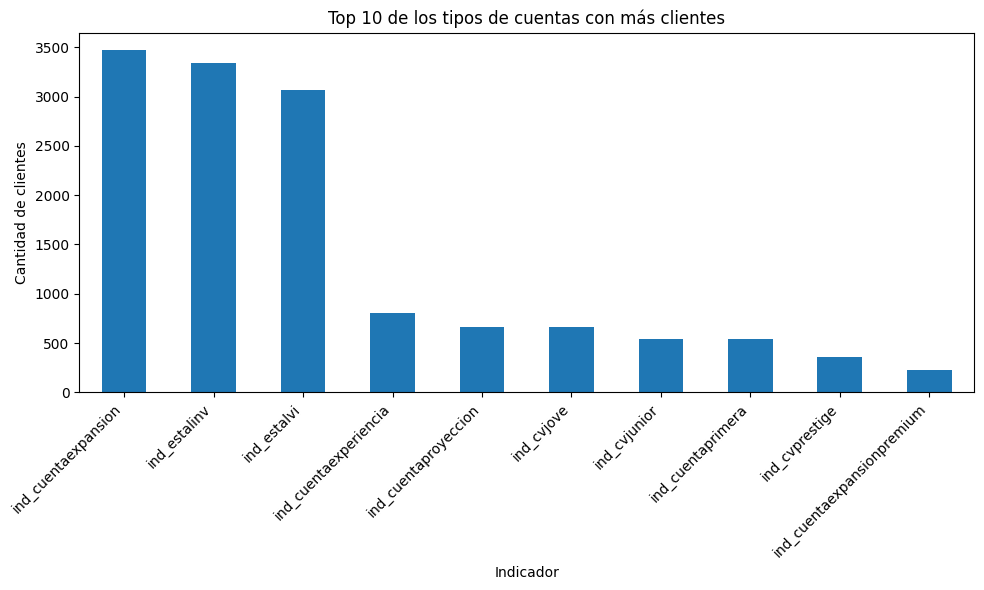

In [ ]:
# Crear gráfico (funcionará ahora que conteo_indicadores está definido)
pd.Series(conteo_indicadores).sort_values(ascending=False).head(10).plot(
    kind='bar',
    title='Top 10 de los tipos de cuentas con más clientes',
    figsize=(10, 6)
)
plt.xlabel('Indicador')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


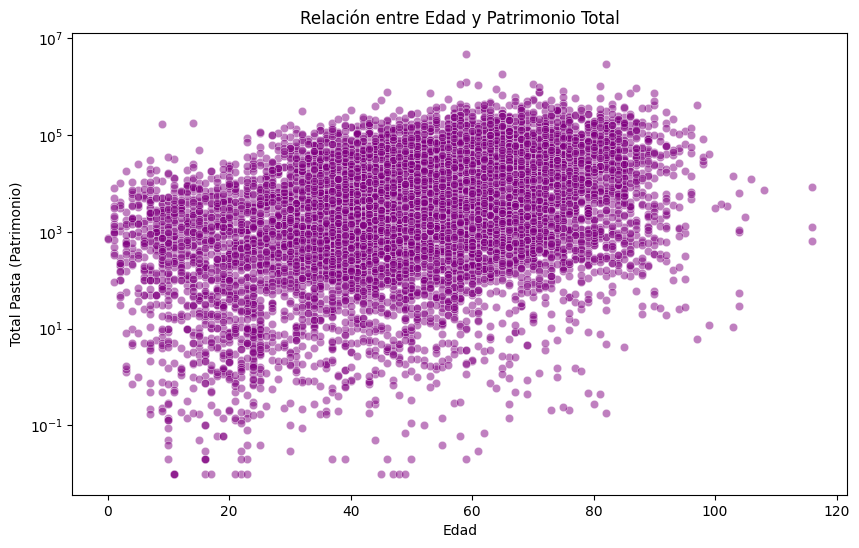

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='edad', y='totalpasta', data=df_datasabadell, alpha=0.5, color='purple')
plt.title('Relación entre Edad y Patrimonio Total')
plt.xlabel('Edad')
plt.ylabel('Total Pasta (Patrimonio)')
plt.yscale('log') # Opcional si hay valores muy altos concentrados
plt.show()

In [ ]:
jovenes = df_datasabadell[df_datasabadell['segmento_edad'] == 'Joven (<=30)'].copy()
print(f'Clientes jóvenes en la muestra: {len(jovenes)}')
print(jovenes['tiene_inversion'].value_counts(normalize=True).round(3))

Clientes jóvenes en la muestra: 1792
tiene_inversion
0    0.797
1    0.203
Name: proportion, dtype: float64


In [ ]:
# Definir data_j antes de usarlo
data_j = jovenes  # o jovenes.copy() si quieres una copia

fig = px.histogram(data_j, x='num_prod_inversion', color='tiene_inversion', nbins=25, barmode='overlay',
                    title='Distribución de productos de inversión en jóvenes',
                    labels={'num_prod_inversion':'Número de productos de inversión'})

fig.show()
print(fig)

NameError: name 'jovenes' is not defined

In [ ]:
# Crear carpeta BD_Actualizada si no existe
bd_actualizada_dir = Path.cwd() / "Output_BD_Actualizada"
bd_actualizada_dir.mkdir(exist_ok=True)

output_file = bd_actualizada_dir / f"datasabadell_actualizado.xlsx"

# Exportar el DataFrame actualizado
df_datasabadell.to_excel(output_file, index=False)
print(f"\nDataFrame exportado exitosamente a: {output_file}")
print(f"Total de registros exportados: {len(df_datasabadell)}")



DataFrame exportado exitosamente a: c:\Users\jmendozarojas\OneDrive - Getronics\Escritorio\INESDI\TFM\Entrega 1 -TFM Ethos\Output_BD_Actualizada\datasabadell_actualizado.xlsx
Total de registros exportados: 9936
